In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, orth, qr
from scipy.optimize import curve_fit
from numpy import sin, cos, pi
cmap = plt.cm.plasma
from scipy.ndimage import gaussian_filter1d
from scipy.signal import wiener
from scipy.signal import wiener, butter, freqs, convolve, freqz
from scipy.fft import fft, ifft, fftshift, ifftshift, fftfreq
from scipy.interpolate import (RegularGridInterpolator, RectBivariateSpline,
                               interpn, griddata, Rbf, interp1d, interp2d)
import cv2
from scipy.signal import convolve2d as conv2
from skimage import color, data, restoration
from smooth_POD_ROM.reduced_order_model import pulse, delta_n_width, train_ROM, L2_error, zielfunktion
from smooth_POD_ROM.pre_processing import convolve_f, gaussian_f, gaussian, smoothen
from smooth_POD_ROM.post_processing import richardson_lucy, post_process
from scipy.optimize import minimize

In [2]:
import numpy as np
from scipy.ndimage import gaussian_filter
from datetime import datetime
im_deconv = np.load("C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/wtf1.npy")
relative_blur = np.load("C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/wtf2.npy")


sgm = 2200/1000
dx = 1/100
truncate = 8
mode = "wrap"
t0 = datetime.now()
blurred = gaussian_filter(
    im_deconv, sigma=sgm/dx, truncate=truncate, mode=mode)  # + eps
t1 = datetime.now()
error_estimate = gaussian_filter(
    relative_blur, sigma=sgm/dx, truncate=truncate, mode=mode)
t2 = datetime.now()
print((t1-t0).total_seconds())
print((t2-t1).total_seconds())
# ads
# for sgm in [10, 50, 100, 500, 1000, 2000]:
#     if sgm > 1000:
#         truncate = 2
#     if sgm > 100:
#         truncate = 4
#     dx = 1
#     mode="wrap"
#     t2 = datetime.now()
#     error_estimate = gaussian_filter(
#         relative_blur, sigma=sgm, truncate=8, mode=mode)
#     t3 = datetime.now()
#     print(_, np.min(relative_blur), np.max(
#         relative_blur), (t3-t2).total_seconds())

0.004023
0.002969


In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 2.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 40

8.030570172000001


In [4]:
m, n = 1000, 10
n_test = 11
x = np.linspace(0, 1, m, endpoint=False)
mu_train = np.linspace(0.0, 1, n, endpoint=False)[:, None]  # +1/(2*n)
#mu_test = np.array([0.2, 0.22, 0.225, 0.23,  0.24, 0.25])[:, None]
mu_test = np.linspace(0.15, 0.2, n_test, endpoint=True)[:, None]
mu_val = x.copy()

interpolatable = (mu_train[0]<mu_val) & (mu_val<mu_train[-1])
mu_val = mu_val[interpolatable][:, None]

sigma = 0.05
num_iter1 = 10
num_iter2 = 100
mode = "constant"
rank = n
dx = 1/m
c = 2
shape = (m,)
clip = True

In [5]:
def plot_paramspace(X, ax=None):
    if not ax:
        print("new ax")
        fig, ax = plt.subplots(figsize=(4.59/2.54, 4.59/2.54))
    ax.imshow(X, interpolation="none", extent=(0, 1, 0, 1), aspect="auto")
    ax.set_xlabel("$\mu$")
    ax.set_ylabel("$x$")
    return ax

In [6]:
X_train = np.empty((m, len(mu_train)))
X_test = np.zeros((m, len(mu_test)))
X_val = np.zeros((m, len(mu_val)))

for _mu, _X in zip([mu_train, mu_test, mu_val], [X_train, X_test, X_val]):
    for j, mu_j in enumerate(_mu):
        y = pulse(x, mu_j)
        _X[:, j] = y
X_train_s = smoothen(X_train, sigma/dx, x.shape, truncate=12)
X_test_s = smoothen(X_test, sigma/dx, x.shape, truncate=12)
X_val_s = smoothen(X_val, sigma/dx, x.shape, truncate=12)

# Fig. 1

C:\Users\florianma\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


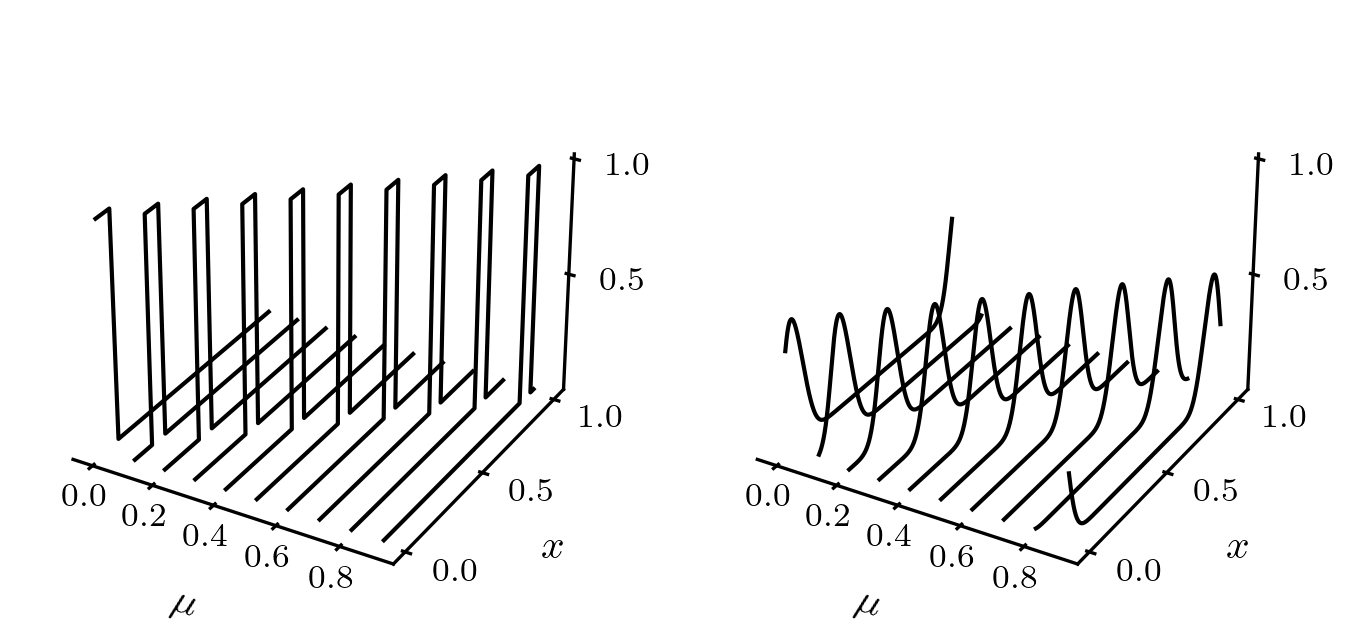

In [6]:
fig = plt.figure(figsize=(page_width_in, page_width_in/2), facecolor='white')
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

for i in range(len(mu_train)):
    ax1.plot(np.ones_like(x)*mu_train[i], x, X_train[:, i], "k-", lw=1)
    ax2.plot(np.ones_like(x)*mu_train[i], x, X_train_s[:, i], "k-", lw=1)
for ax in (ax1, ax2):
    ax.xaxis.labelpad = -5
    ax.yaxis.labelpad = -5
    xticks = [0.0, 0.2, 0.4, 0.6, 0.8]
    yticks = [0.0, 0.5, 1.0]
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.set_zticks([0.5, 1.0])
    ax.tick_params(axis='x', which='major', pad=-5)
    ax.tick_params(axis='y', which='major', pad=-2)
    ax.tick_params(axis='z', which='major', pad=0)
    ax.set_yticklabels(yticks, va='baseline', ha='left')
    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        for tick in axis.get_major_ticks():
            tick.label1.set_fontsize(8)  # for some reasons it does not match
        axis.pane.set_edgecolor('white')

    ax.grid(False)
    ax.set_facecolor('white')
    ax.xaxis.pane.fill = False  # Remove the background pane
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.set_xlabel("$\mu$")
    ax.set_ylabel("$x$")
plt.show()


In [7]:
standard_rom = train_ROM(mu_train, X_train, rank=rank)
X_test_ROM = standard_rom.predict(mu_test).T
X_val_ROM = standard_rom.predict(mu_val).T

X_train_s = smoothen(X_train, sigma/dx, shape)
smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
X_test_sROM = smooth_rom.predict(mu_test).T
X_val_sROM = smooth_rom.predict(mu_val).T

X_test_sROMs = post_process(x, X_test_sROM, sigma, c, mu_test, mu_train, num_iter1,
                            shape, clip=clip, progress=False)
X_test_sROMs2 = post_process(x, X_test_sROM, sigma, c, mu_test, mu_train, num_iter2,
                            shape, clip=clip, progress=False)

pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/Pulse/"
np.save(pth+"X_test.npy", X_test)
np.save(pth+"X_test_s.npy", X_test_s)
np.save(pth+"X_test_ROM.npy", X_test_ROM)
np.save(pth+"X_test_sROM.npy", X_test_sROM)

\\files.ad.ife.no\MatPro_files\Florian\Repositoties\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:24: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


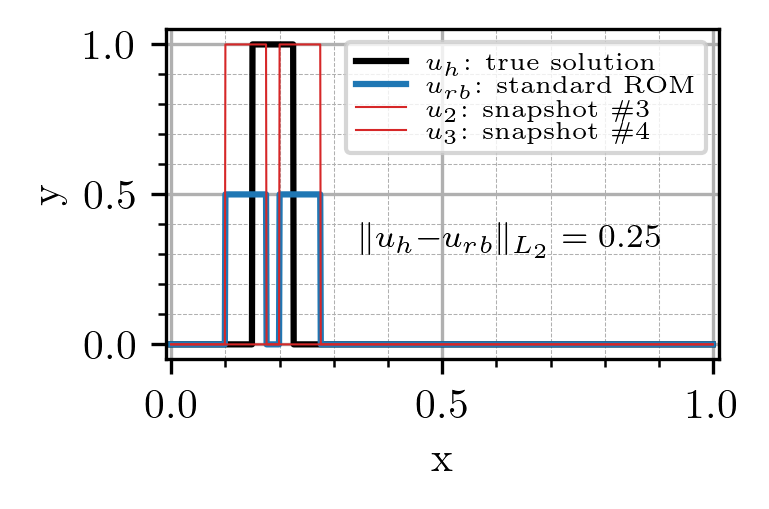

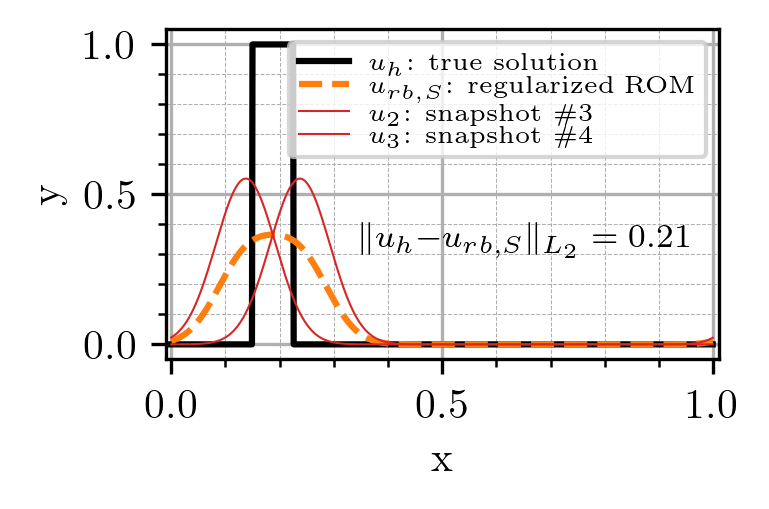

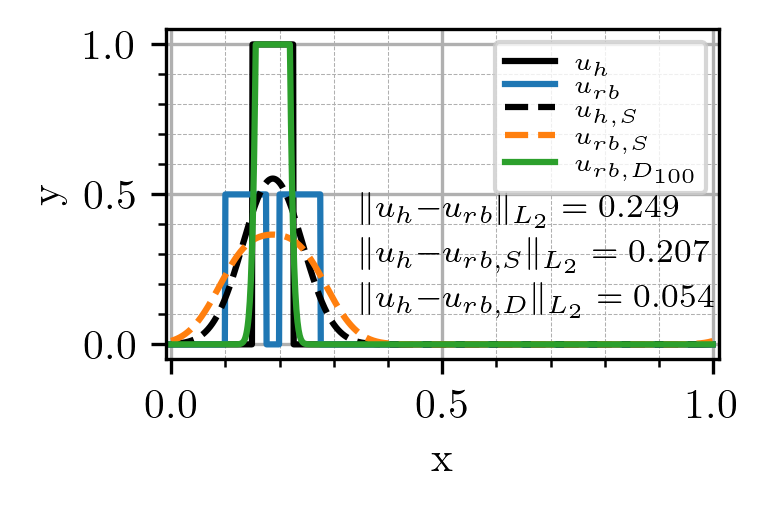

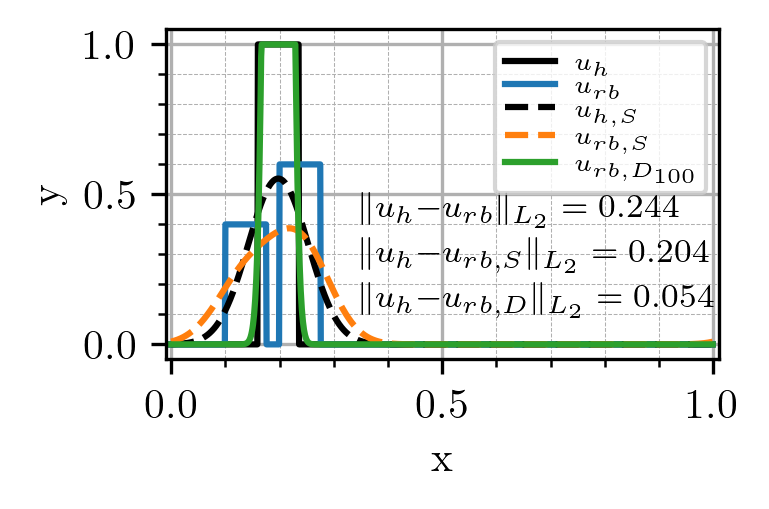

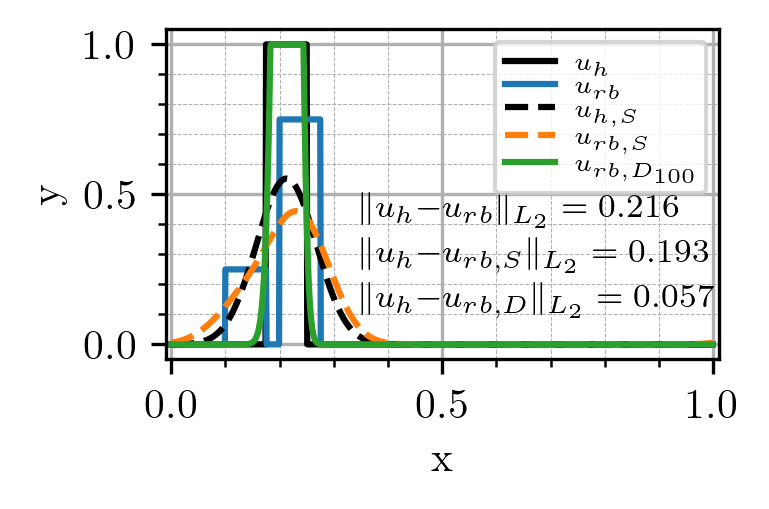

In [8]:
mu_plot = 0.2

i_c = 0  # snapshots centered between 2 training points
for _X, _X_R, lbl, col in zip([X_train, X_train_s], [X_test_ROM, X_test_sROM],
                              ["$u_{rb}$: standard ROM", "$u_{rb, S}$: regularized ROM"], ["C0-", "C1--"]):
    fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
    #plt.plot(x, pulse(x, mu_plot), "kx-", ms=4, markevery=markevery, label="$u_h$: true solution")
    plt.plot(x, X_test[:, i_c], "k-", ms=4, markevery=markevery, label="$u_h$: true solution")
    #plt.plot(x, X_test_ROM[:, 0], "b.-", label="ROM")
    plt.plot(x, _X_R[:, i_c], col, ms=4, markevery=markevery, label=lbl)
    #plt.plot(x, X[:, 3], "r--", lw=1, label="closest snapshot (left)")
    #plt.plot(x, X[:, 4], "r--", lw=1, label="closest snapshot (right)")
    plt.plot(x, _X[:, 1], "C3-", lw=.5, ms=4, markevery=(30, markevery), label="$u_{2}$: snapshot \#3")
    plt.plot(x, _X[:, 2], "C3-", lw=.5, ms=4, markevery=(30, markevery), label="$u_{3}$: snapshot \#4")
    ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    plt.grid(True, which='minor', linestyle='--', lw=.25)
    plt.grid(True, which='major', linestyle='-')
    plt.legend()
    e = np.mean((X_test[:, 0]-_X_R[:, 0])**2)**.5
    ax.text(0.35, 0.35, "$\|u_h-$"+lbl.split(":")[0]+"$\|_{L_2}"+"={:.2f}$".format(e), fontsize=8, va="center")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim(-0.01, 1.01)
    plt.ylim(-0.05, 1.05)
    plt.show()

if m == 1001:
    a_list = [0, 5, 10]
else:
    a_list = [0, 2, 5]

for j in a_list:
    markevery = 45
    fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
    plt.plot(x, X_test[:, j], "k-", ms=4, markevery=(0, markevery), label="$u_h$") # : true solution
    plt.plot(x, X_test_ROM[:, j], "C0-", ms=4, markevery=(10, markevery), label="$u_{rb}$") # : standard ROM
    plt.plot(x, X_test_s[:, j], "k--", ms=4, markevery=(20, markevery), label="$u_{h, S}$") # : regularized true solution
    plt.plot(x, X_test_sROM[:, j], "C1--", ms=4, markevery=markevery, label="$u_{rb, S}$") # : regularized ROM
    plt.plot(x, X_test_sROMs2[:, j], "C2-", ms=4, markevery=(30, markevery), label="$u_{rb, D_{100}}$") # : deconvolved reg. ROM
#     plt.plot(x, X_test_sROMs2[:, j], "C3|-", ms=4, markevery=markevery, label="$u_{rb, D_{100}}$") # : deconvolved reg. ROM
    ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, 2, 21, endpoint=True), minor=True)
    
    e = np.mean((X_test[:, j]-X_test_ROM[:, j])**2)**.5
    ax.text(0.35, 0.45, "$\|u_h{-u_{rb}}\|_{L_2}"+"={:.3f}$".format(e), fontsize=8, va="center")
    
    e = np.mean((X_test[:, j]-X_test_sROM[:, j])**2)**.5
    ax.text(0.35, 0.3, "$\|u_h{-u_{rb,S}}\|_{L_2}"+"={:.3f}$".format(e), fontsize=8, va="center")
    
    e = np.mean((X_test[:, j]-X_test_sROMs2[:, j])**2)**.5
    ax.text(0.35, 0.15, "$\|u_h{-u_{rb,D}}\|_{L_2}"+"={:.3f}$".format(e), fontsize=8, va="center")
    
#     e = np.mean((X_test[:, j]-X_test_sROMs2[:, j])**2)**.5
#     ax.text(0.35, 0.0, "$\|u_h{-u_{rb,D_{1000}}}\|_{L_2}"+"={:.3f}$".format(e), fontsize=8, va="center")
    
    plt.grid(True, which='minor', linestyle='--', lw=0.25)
    plt.grid(True, which='major', linestyle='-')
    plt.legend()
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim(-0.01, 1.01)
    plt.ylim(-0.05, 1.05)
    plt.show()

# brute force search for sigma_s (per snapshot!)

0.0
0.005
0.01
0.015
0.02
0.025
0.03
0.035
0.04
0.045
0.05
0.055
0.06
0.065
0.07
0.075
0.08
0.085
0.09
0.095
0.1
[0.15]


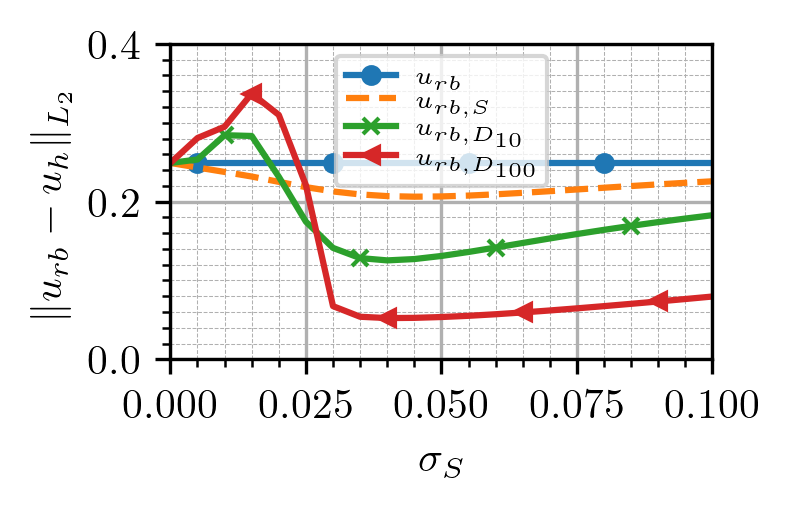

[0.155]


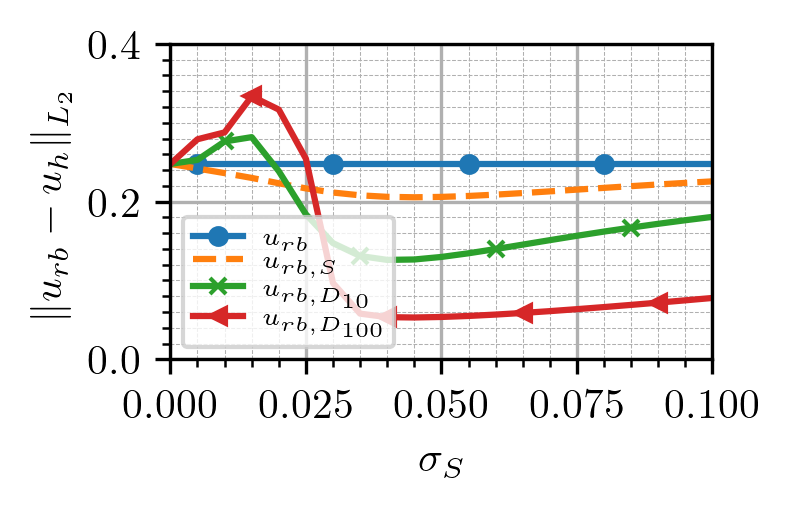

[0.16]


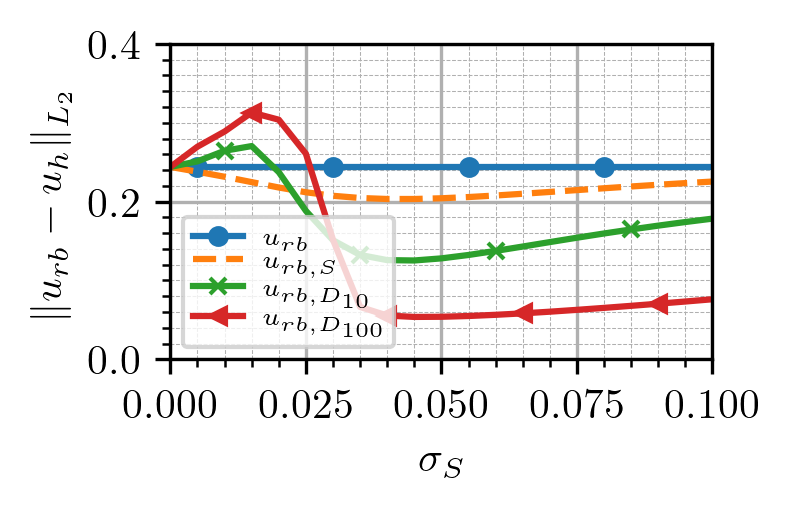

[0.165]


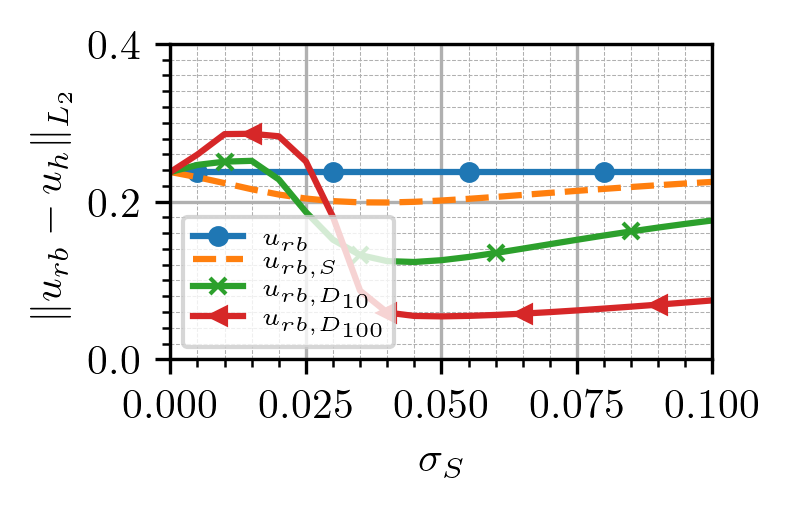

[0.17]


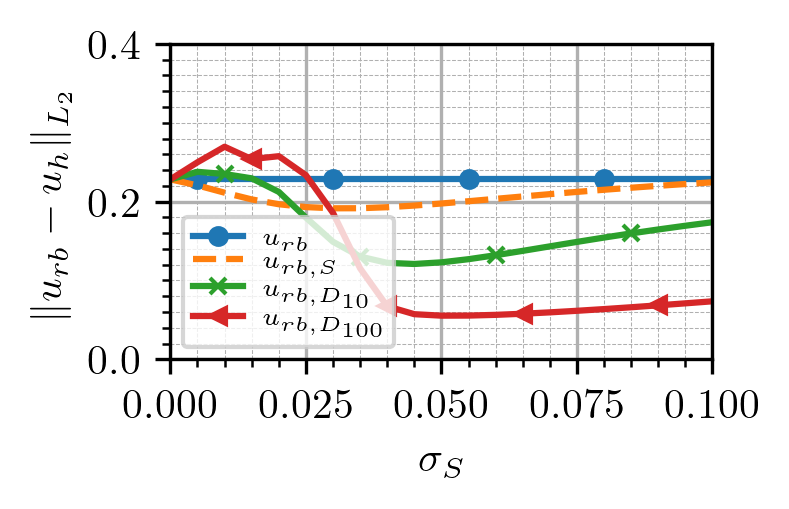

[0.175]


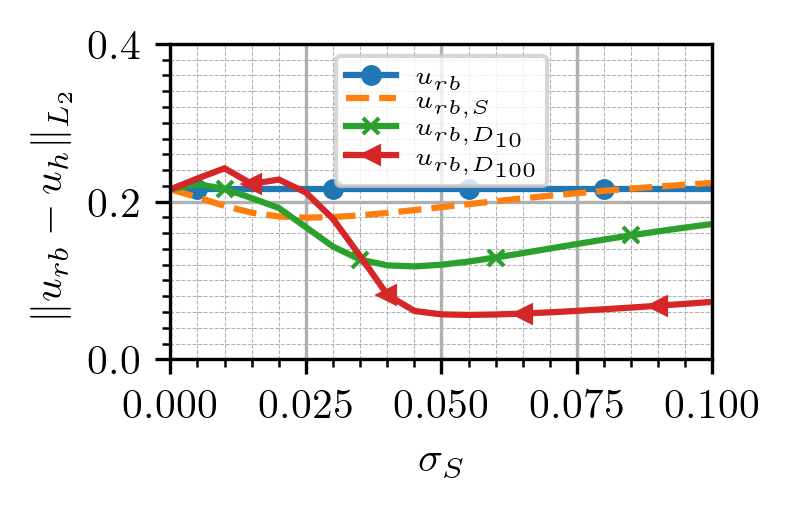

[0.18]


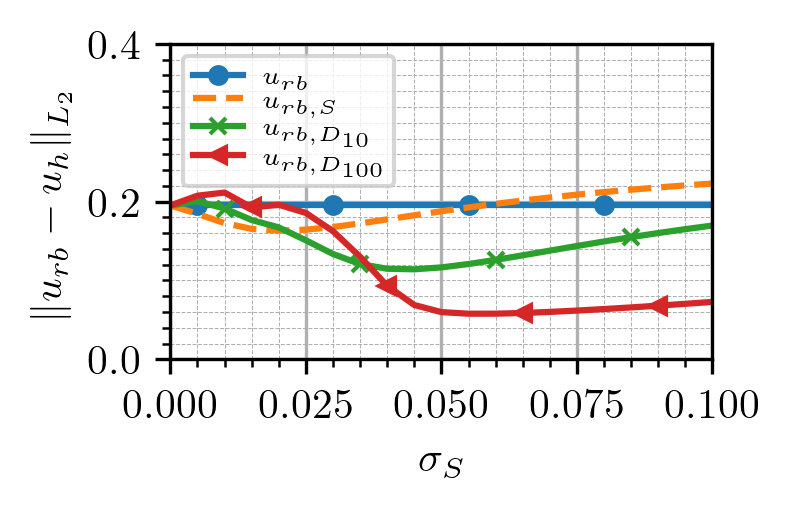

[0.185]


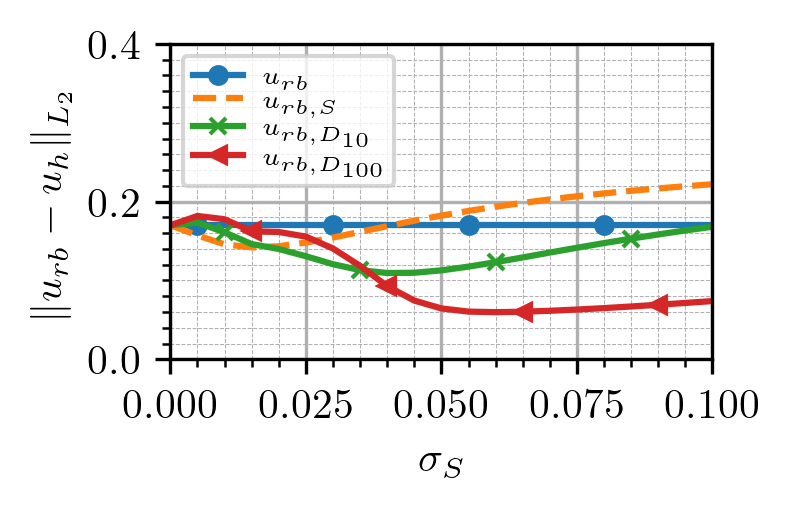

[0.19]


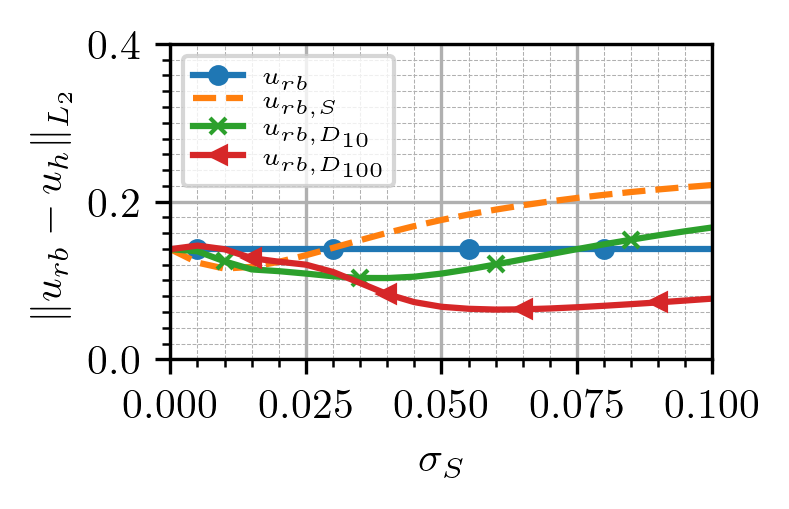

[0.195]


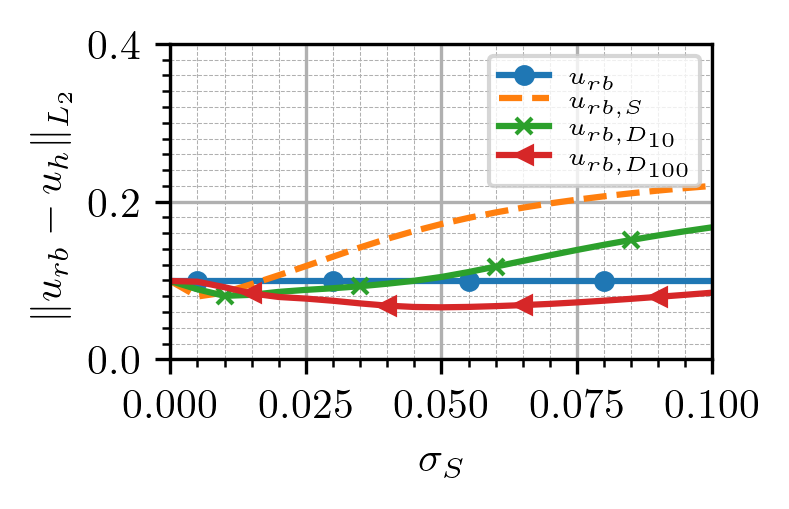

[0.2]


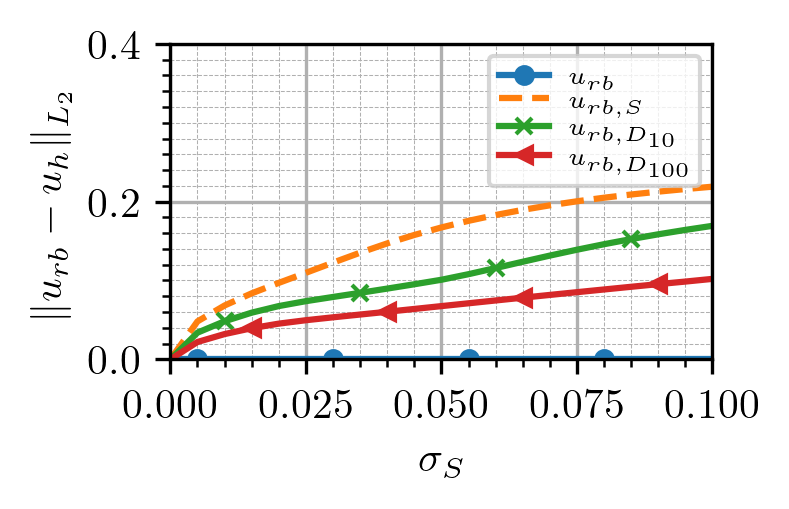

In [9]:
# for snapshots in mu_test
# for sigma_s in [0.0, ..., 0.2]
# sigma_d = 2*sigma_s
# smooth rom
c = 2
sgms = np.linspace(0, 0.1, 21)
eROM = L2_error(X_test_ROM, X_test)
esROM = np.zeros((n_test, 21))
esROMs = np.zeros((n_test, 21))
esROMs2 = np.zeros((n_test, 21))
for i, sigma_s in enumerate(sgms):
    print(sigma_s)
    X_train_s = smoothen(X_train, sigma_s/dx, shape)
    smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
    X_test_sROM = smooth_rom.predict(mu_test).T
    esROM[:, i] = L2_error(X_test_sROM, X_test)
    # de smoothing
    X_test_sROMs = post_process(x, X_test_sROM, sigma_s, c, mu_test, mu_train,
                                num_iter1, shape=shape, clip=clip)
    esROMs[:, i] = L2_error(X_test_sROMs, X_test)
    # de smoothing with a higher number of iterations
    X_test_sROMs2 = post_process(x, X_test_sROM, sigma_s, c, mu_test, mu_train,
                                num_iter2, shape=shape, clip=clip)
    esROMs2[:, i] = L2_error(X_test_sROMs2, X_test)


me = 5
for p in range(n_test):
    print(mu_test[p])
    fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
    plt.plot(sgms, np.full(sgms.shape, eROM[p]), "C0o-", ms=4, markevery=(1, me), label="$u_{rb}$")
    plt.plot(sgms, esROM[p, :], "C1--", ms=4, markevery=me, label="$u_{rb,S}$")
    plt.plot(sgms, esROMs[p, :], "C2x-", ms=4, markevery=(2, me), label="$u_{rb,D_{10}}$")
    plt.plot(sgms, esROMs2[p, :], "C3<-", ms=4, markevery=(3, me), label="$u_{rb,D_{100}}$")
    plt.legend()
    plt.ylabel("$\|u_{rb}-u_h\|_{L_2}$")
    plt.xlabel("$\sigma_S$")
    plt.xlim(0, .1)
    plt.ylim(0, 0.4)
    ax.set_xticks(np.linspace(0, .1, 21, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, .4, 21, endpoint=True), minor=True)
    plt.grid(True, which='minor', linestyle='--', lw=.25)
    plt.grid(True, which='major', linestyle='-')
    plt.show()

# brute force search for c (per snapshot!)

0.0
0.5
1.0
1.5
2.0
2.5
3.0
3.5
4.0
4.5
5.0
5.5
6.0
6.5
7.0
7.5
8.0
8.5
9.0
9.5
10.0
[0.15]


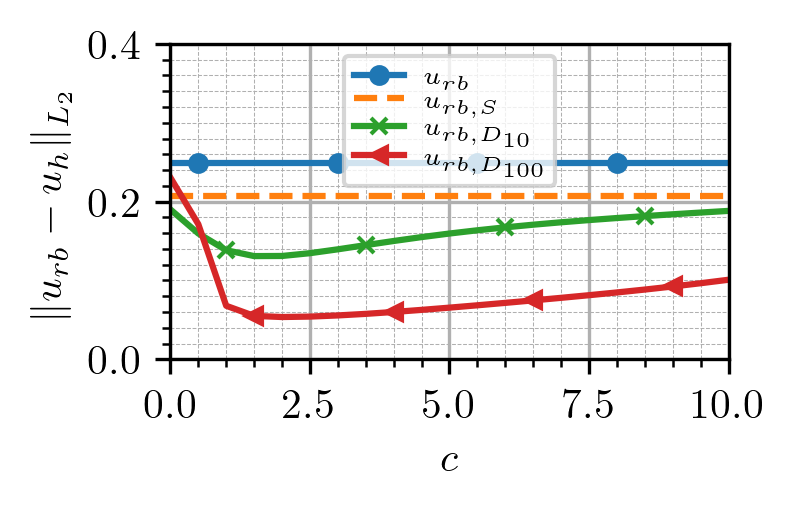

[0.155]


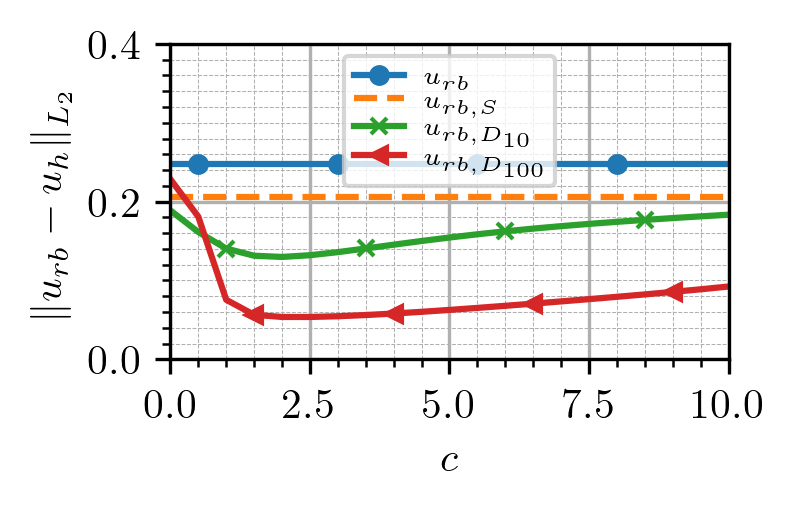

[0.16]


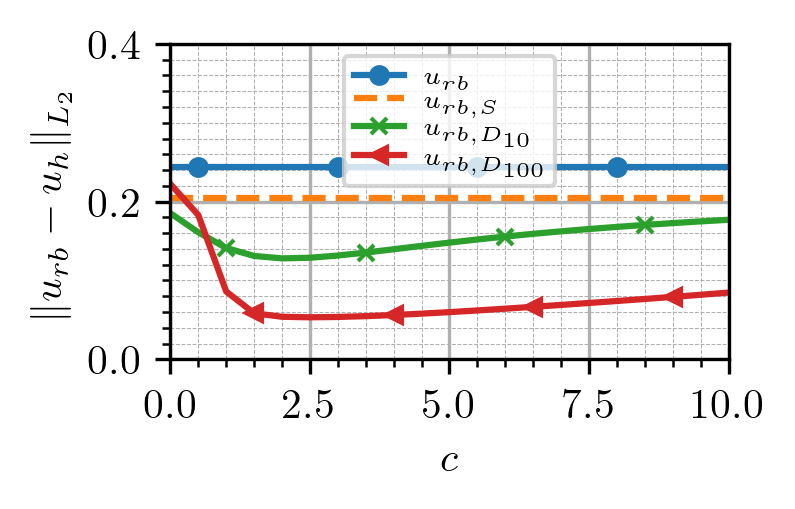

[0.165]


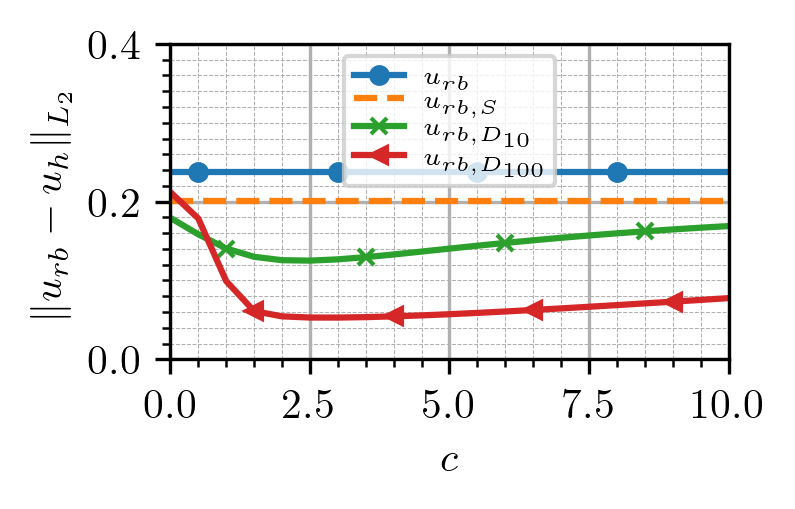

[0.17]


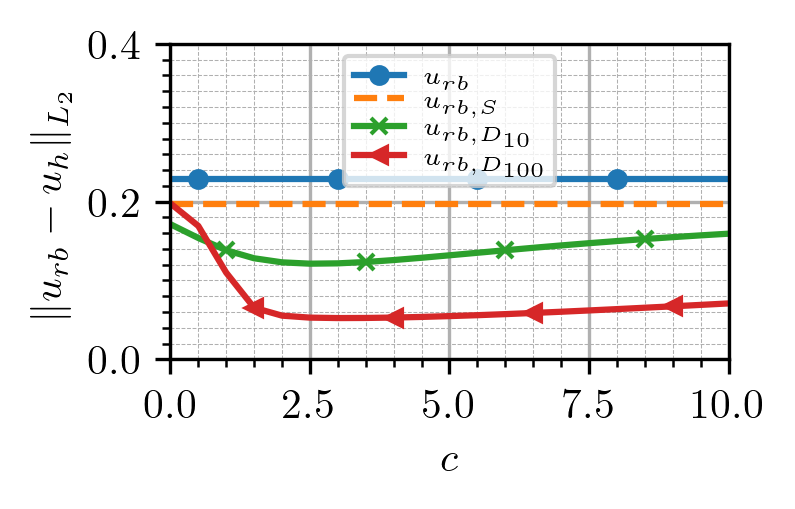

[0.175]


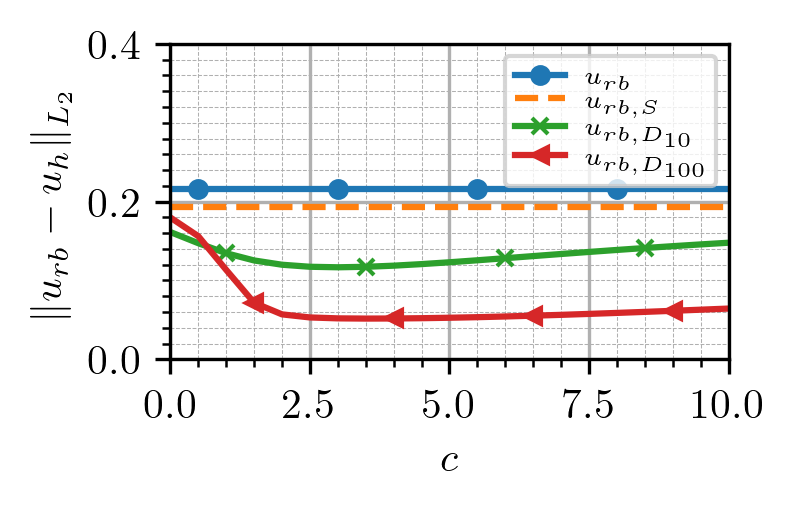

[0.18]


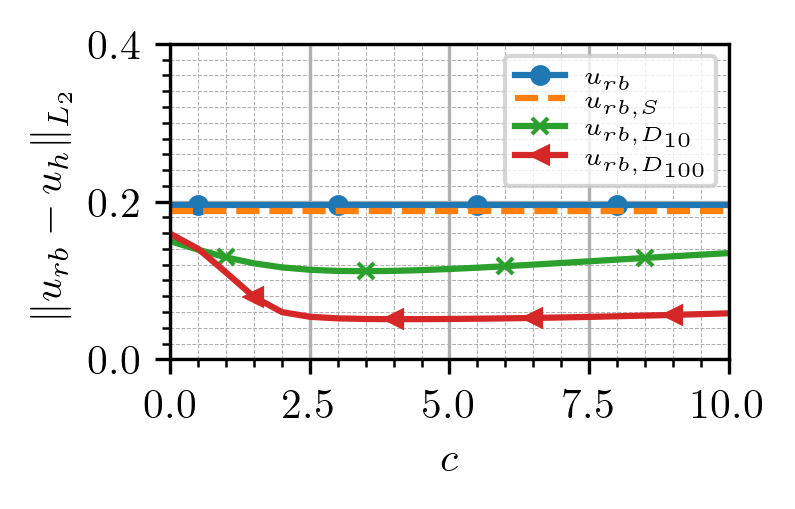

[0.185]


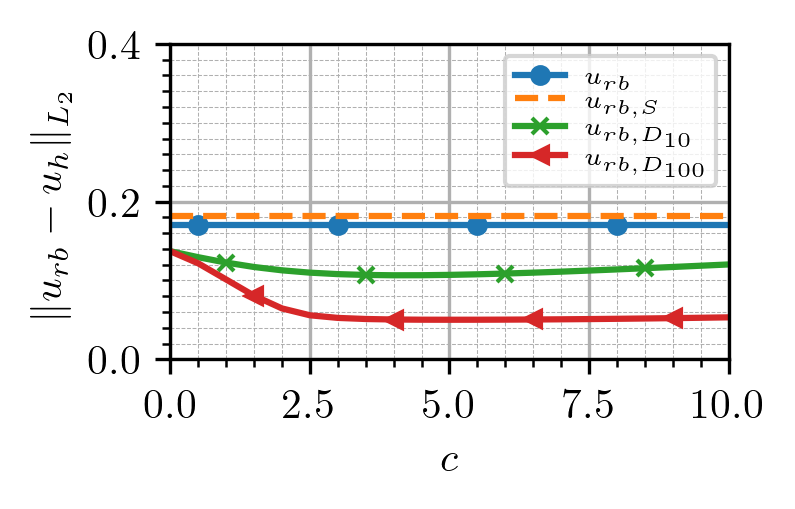

[0.19]


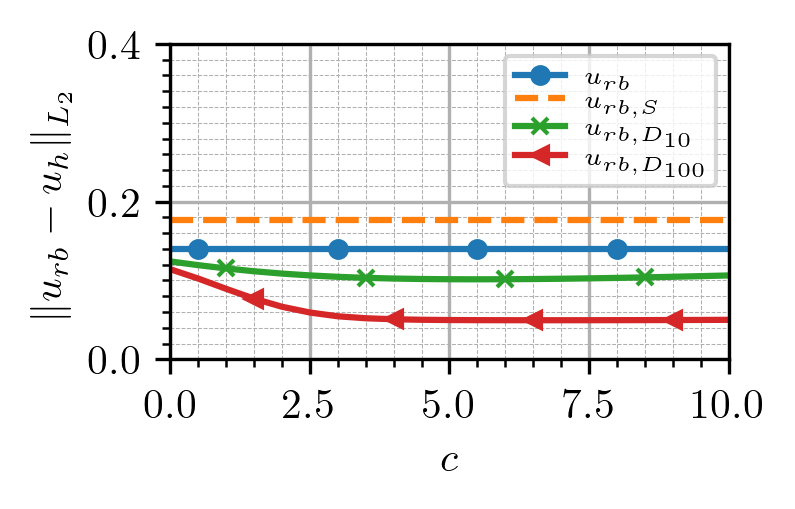

[0.195]


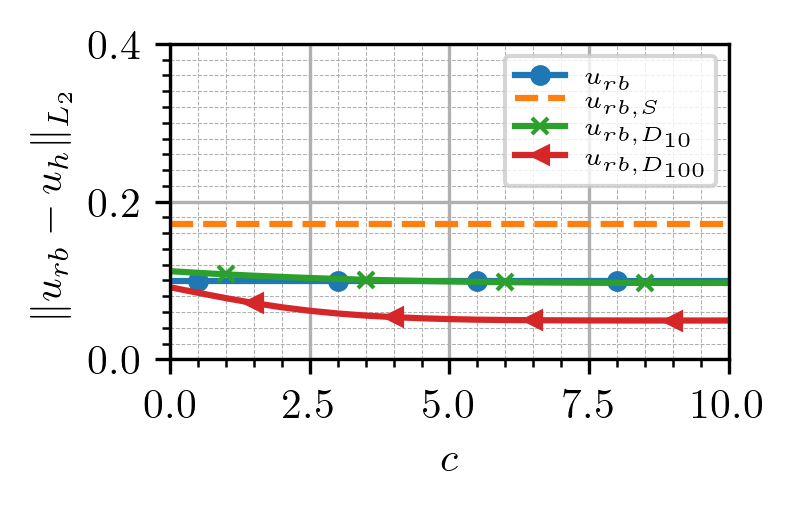

[0.2]


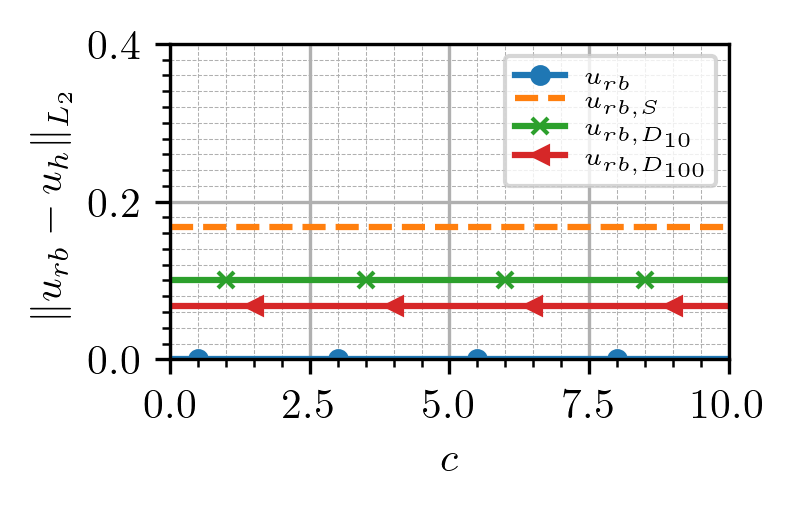

In [10]:
# for snapshots in mu_test
# for sigma_s in [0.0, ..., 0.2]
# sigma_d = 2*sigma_s
# smooth rom
sigma_s = 0.05
cs = np.linspace(0, 10, 21)
eROM = L2_error(X_test_ROM, X_test)
esROMs = np.zeros((n_test, 21))
esROMs2 = np.zeros((n_test, 21))

X_train_s = smoothen(X_train, sigma_s/dx, shape)
smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
X_test_sROM = smooth_rom.predict(mu_test).T
esROM = L2_error(X_test_sROM, X_test)
for i, c in enumerate(cs):
    print(c)
    # de smoothing
    X_test_sROMs = post_process(x, X_test_sROM, sigma_s, c, mu_test, mu_train,
                                num_iter1, shape=shape, clip=clip)
    esROMs[:, i] = L2_error(X_test_sROMs, X_test)
    # de smoothing with a higher number of iterations
    X_test_sROMs2 = post_process(x, X_test_sROM, sigma_s, c, mu_test, mu_train,
                                num_iter2, shape=shape, clip=clip)
    esROMs2[:, i] = L2_error(X_test_sROMs2, X_test)

    
me = 5
for p in range(n_test):
    print(mu_test[p])
    fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
    plt.plot(cs, np.full(cs.shape, eROM[p]), "C0o-", ms=4, markevery=(1, me), label="$u_{rb}$")
    plt.plot(cs, np.full(cs.shape, esROM[p]), "C1--", ms=4, markevery=me, label="$u_{rb,S}$")
    plt.plot(cs, esROMs[p, :], "C2x-", ms=4, markevery=(2, me), label="$u_{rb,D_{10}}$")
    plt.plot(cs, esROMs2[p, :], "C3<-", ms=4, markevery=(3, me), label="$u_{rb,D_{100}}$")
    plt.legend()
    plt.ylabel("$\|u_{rb}-u_h\|_{L_2}$")
    plt.xlabel("$c$")
    plt.xlim(0, .1)
    plt.ylim(0, 0.4)
    ax.set_xticks(np.linspace(0, 10, 21, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, .4, 21, endpoint=True), minor=True)
    plt.grid(True, which='minor', linestyle='--', lw=.25)
    plt.grid(True, which='major', linestyle='-')
    plt.show()

In [11]:
bf = False
if bf:
    n_s = 41
    sgms = np.linspace(0.0, 0.2, n_s)
    e1 = np.zeros((len(mu_val), n_s),)-1
    e2 = np.zeros((len(mu_val), n_s),)-1

    esROM = np.empty(len(mu_val), )
    eROM = np.empty(len(mu_val), )
    esROMs = np.empty(len(mu_val), )
    sgm_opt = np.empty(len(mu_val), )

    for p in range(len(mu_val)):
#         if np.round(mu_val[p], decimals=3) not in mu_test:
#             continue
        exact = X_val[:, p]
        standard_ROM = X_val_ROM[:, p]
        blurred = np.copy(X_val_sROM[:, p])
        esROM[p] = np.mean((blurred-X_val[:, p])**2)**.5
        eROM[p] = np.mean((standard_ROM-X_val[:, p])**2)**.5


        for i, sgm in enumerate(sgms):
            deconvolved_RL = richardson_lucy(x, blurred, sgm, num_iter=num_iter1, damping=2, clip=clip)
            e1[p, i] = np.mean((deconvolved_RL-X_val[:, p])**2)**.5

        ind = np.argmin(e1[p])
        sgm_opt[p] = sgms[ind]
        esROMs[p] = e1[p, ind]

        print(p, mu_val[p], ind, sgm_opt[p], e1[p, ind])

        if np.round(mu_val[p], decimals=3) in [0.15, 0.175, 0.2]:
            for i, sgm in enumerate(sgms):
                deconvolved_RL = richardson_lucy(x, blurred, sgm, num_iter=num_iter2, damping=2, clip=clip)
                e2[p, i] = np.mean((deconvolved_RL-X_val[:, p])**2)**.5
            
            me = 10
            fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
            plt.plot(sgms, np.full(sgms.shape, eROM[p]), "C0o-", ms=4, markevery=(5, me), label="$u_{rb}$")
            plt.plot(sgms, np.full(sgms.shape, esROM[p]), "C1--", ms=4, markevery=me, label="$u_{rb,S}$")
            plt.plot(sgms, e1[p], "C2x-", ms=4, markevery=(5, me), label="$u_{rb,D_{10}}$")
            plt.plot(sgms, e2[p], "C3<-", ms=4, markevery=(20, me), label="$u_{rb,D_{100}}$")
            plt.legend()
            plt.ylabel("$\|u_{rb}-u_h\|_{L_2}$")
            plt.xlabel("$\sigma_D$")
            plt.xlim(0, .2)
            plt.ylim(0, 0.4)
            plt.legend()
            ax.set_xticks(np.linspace(0, .2, 11, endpoint=True), minor=True)
            ax.set_yticks(np.linspace(0, .4, 19, endpoint=True), minor=True)
            plt.grid(True, which='minor', linestyle='--', lw=.25)
            plt.grid(True, which='major', linestyle='-')
            plt.show()

            deconvolved_RL = richardson_lucy(x, blurred, sgm_opt[p], num_iter=num_iter1, damping=2, clip=clip)

            plt.plot(x, standard_ROM, "C0.", label="standard ROM")
            plt.plot(x, blurred, "C1.", label="smooth ROM")
            plt.plot(x, X_val[:, p], "C2.", label="exact solution")
            plt.plot(x, X_val_s[:, p], "C3.", label="exact solution (smooth)")
            plt.plot(x, deconvolved_RL, "C4.", label="richarson Lucy deconvolution")
            plt.legend()
            plt.xlabel("$x$")
            plt.ylabel("$y$")
            plt.show()


    plt.plot(mu_val, eROM, "C0.", label="standard ROM")
    plt.plot(mu_val, esROM, "C1.", label="smooth ROM")
    plt.plot(mu_val, esROMs, "C2.", label="RL")
    plt.xlabel("error")
    plt.xlabel("$\mu$")
    plt.legend()
    plt.show()

    print(np.mean(esROM/eROM))
    plt.plot(mu_val, sgm_opt, "C0.")
    plt.xlabel("$\mu$")
    plt.ylabel("$\sigma$")
    plt.show()

In [12]:
if bf:
    plt.plot(mu_val, sgm_opt, "C0.")
    plt.ylim(0.05, 0.2)
    plt.show()

    ind = np.argmin(np.abs(sgms-sigma))
    plt.plot(mu_val, e1[:, ind], "C0.")

    ind = np.argmin(np.abs(sgms-2*sigma))
    fig, ax = plt.subplots()
    plt.plot(mu_val, e1[:, ind], "C1.")
    plt.plot(mu_val, np.min(e1, axis=1), "C2.")
    #plt.xlim(0.2, 0.5)
    #plt.ylim(1.8, 2.0)
    plt.xlabel("$\mu$")
    plt.ylabel("$e$")
    left, right, bottom, top = sgms[0], sgms[-1], mu_val[0, 0], mu_val[-1, 0]

    fig, ax2 = plt.subplots()
    plt.imshow(e1, vmin=0.0, vmax=0.15, extent=(left, right, bottom, top), origin="lower", interpolation="nearest")  # 
    plt.gca().set_aspect("auto")
    for p, _mu in enumerate(mu_val):
        d = np.min(np.abs(_mu-mu_train))
        ind2 = np.argmin(np.abs(sgms - (sigma+1*d)))

        ax.plot(_mu, e1[p, ind2], "r.")
        plt.plot(sigma+1*d, _mu, "b.", ms=1)

        ind = np.argmin(e1[p, :])
        plt.plot(sgms[ind], _mu, "r.", ms=1)
    plt.show()

# truncation leads to bad results

0.050000, 2.0000, 0.05277876, -51.6396 %
3.400591839029715e-16 0.16723160444359678 0.06752008885965675


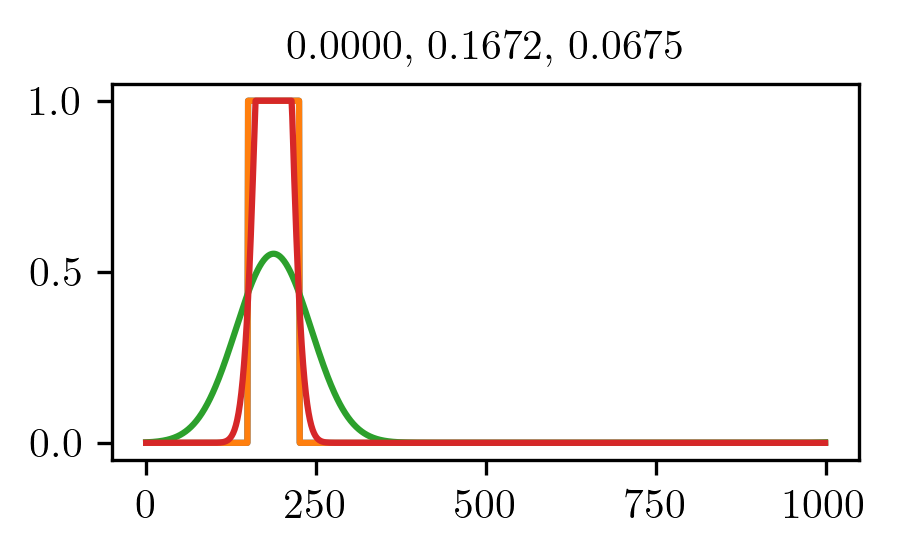

0.09486832980505137 0.17069615678452704 0.04992748660980465


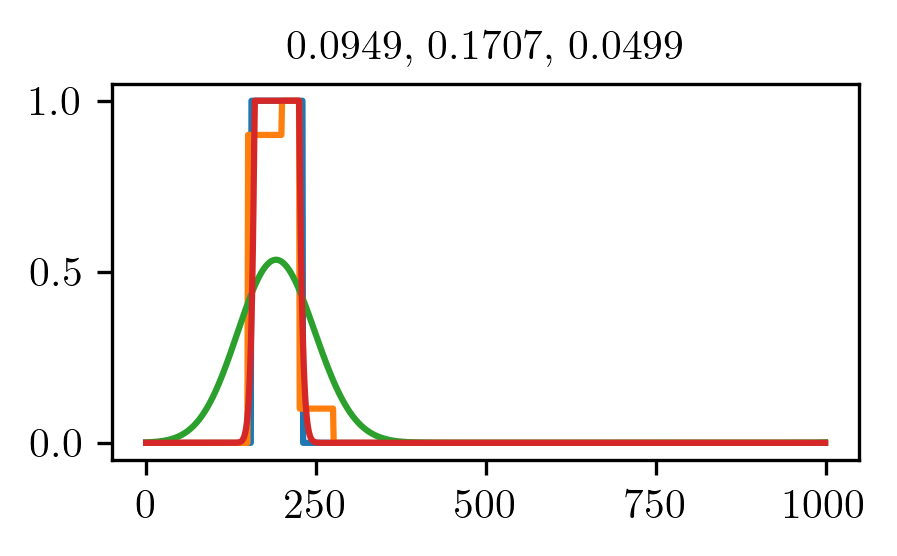

0.12649110640673517 0.17373910930159023 0.04912688163172009


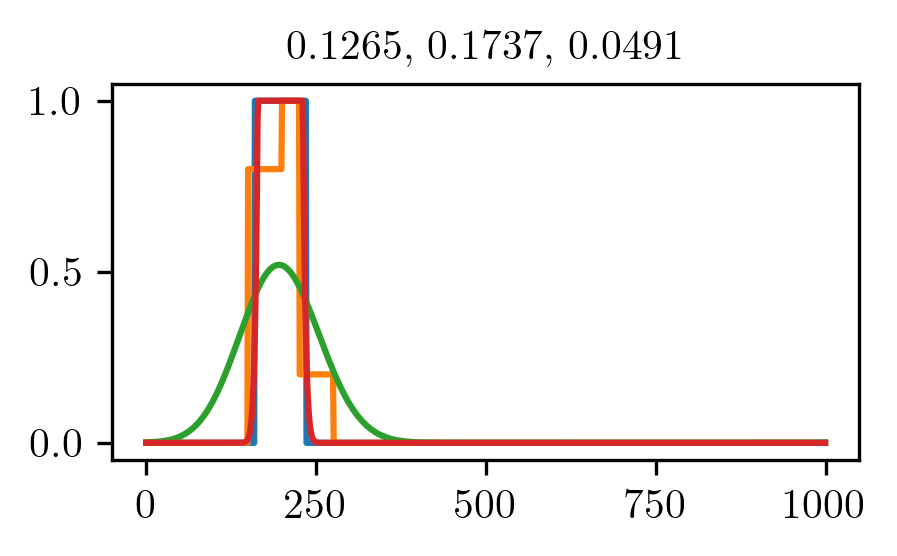

0.1449137674618944 0.17609757837329104 0.04928076853314692


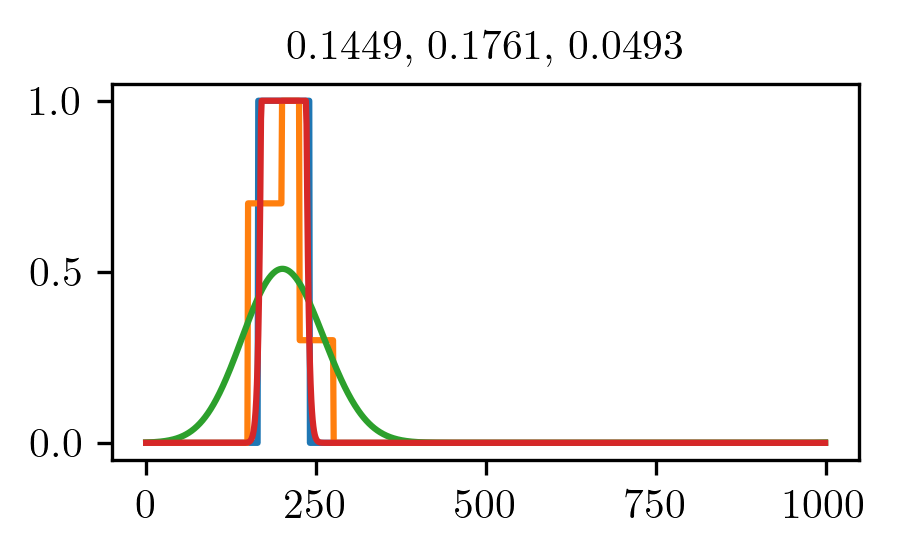

0.15491933384829668 0.1775860139351104 0.049468984292953794


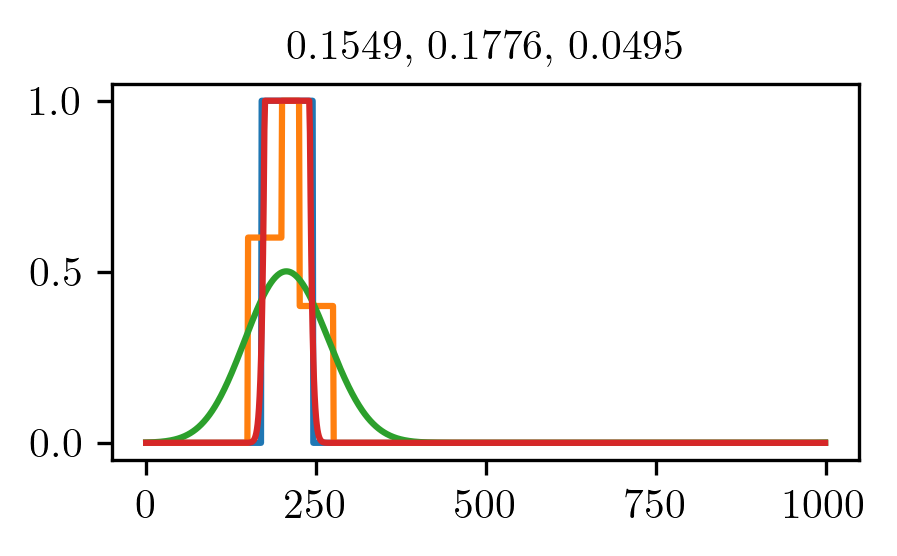

0.15811388300841897 0.1780943144002551 0.049917902956437325


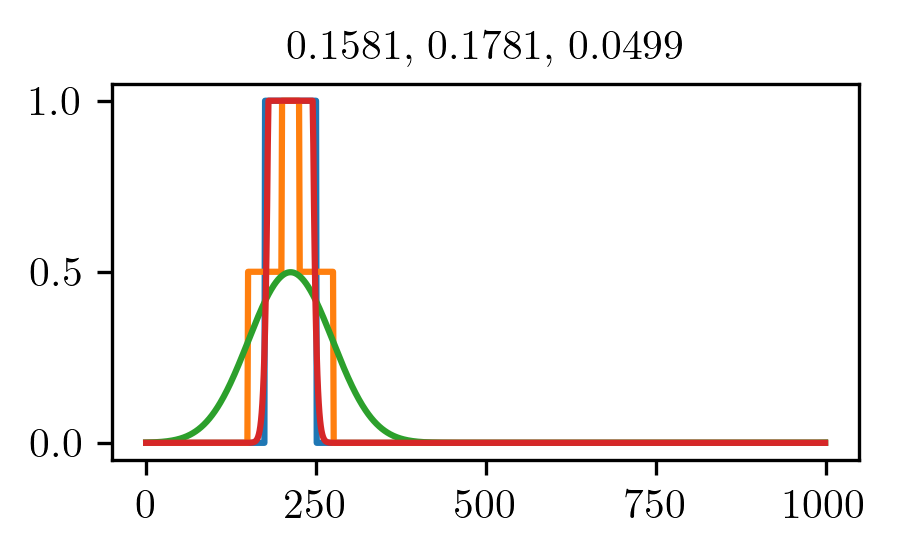

0.15491933384829673 0.17758601393511037 0.04946898429295387


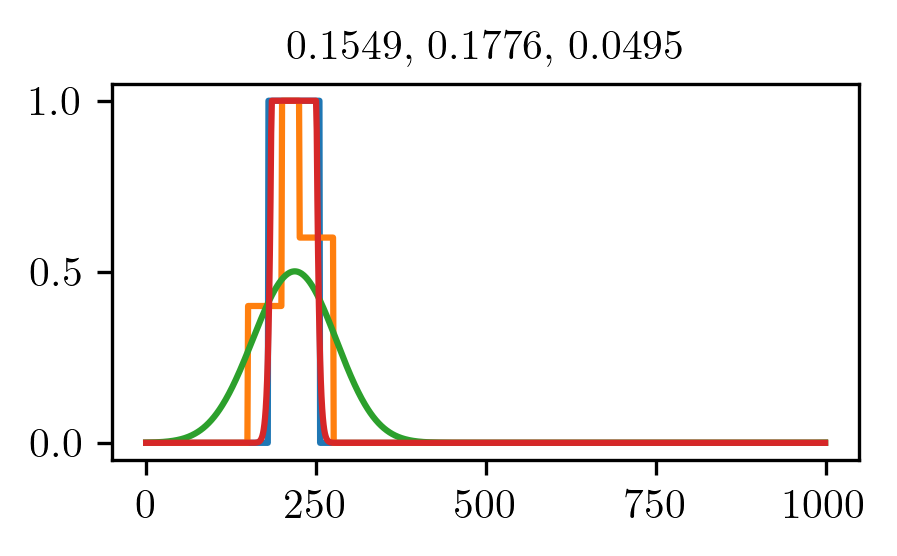

0.1449137674618944 0.17609757837329107 0.049280768533147


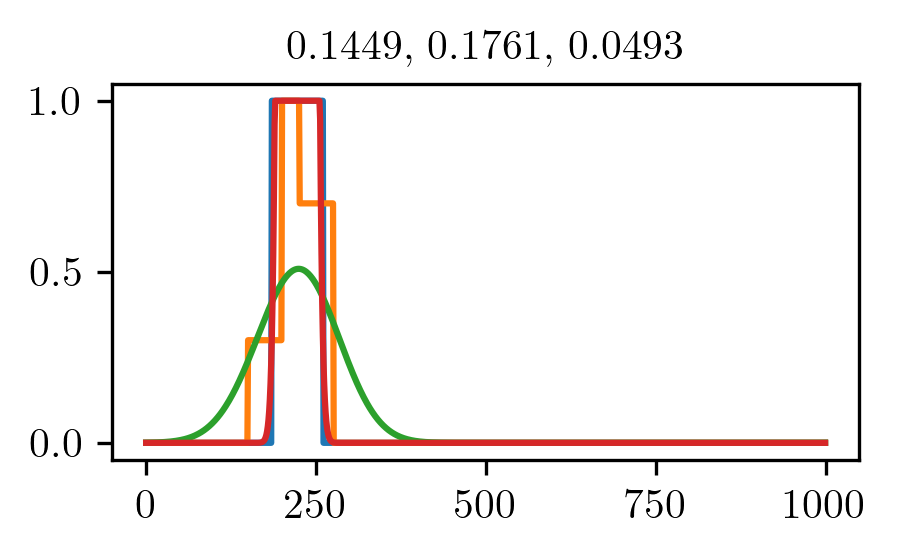

0.1264911064067352 0.17373910930159023 0.04912688163172023


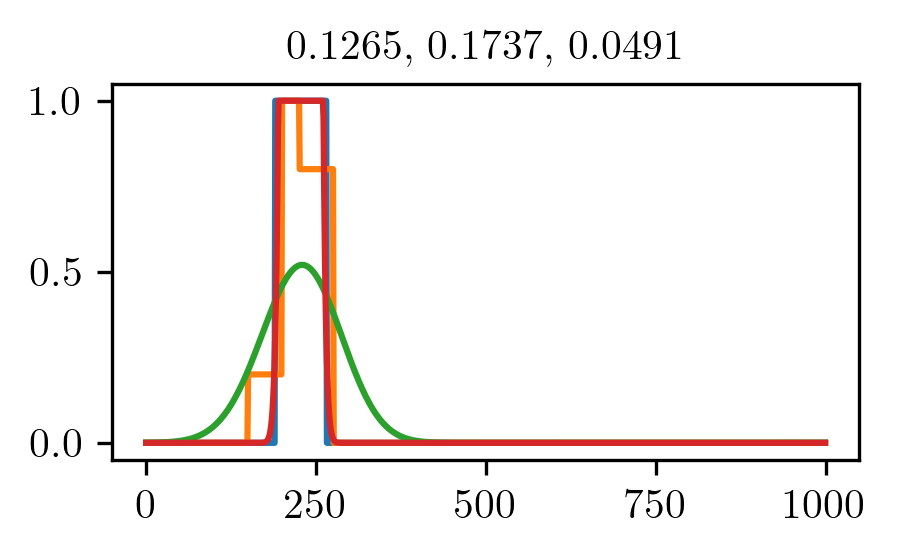

0.09486832980505139 0.17069615678452704 0.049927486609804735


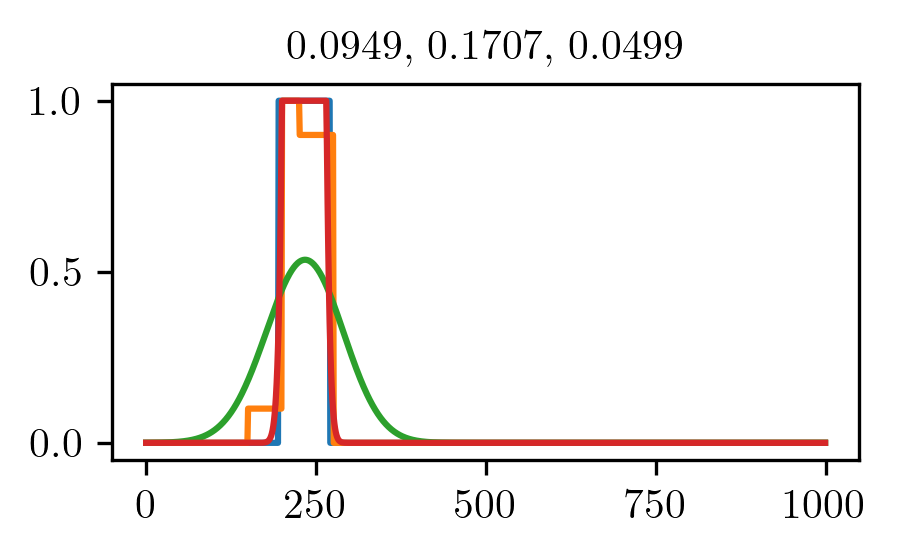

4.2495094290609017e-16 0.16723160444359672 0.06752008885965351


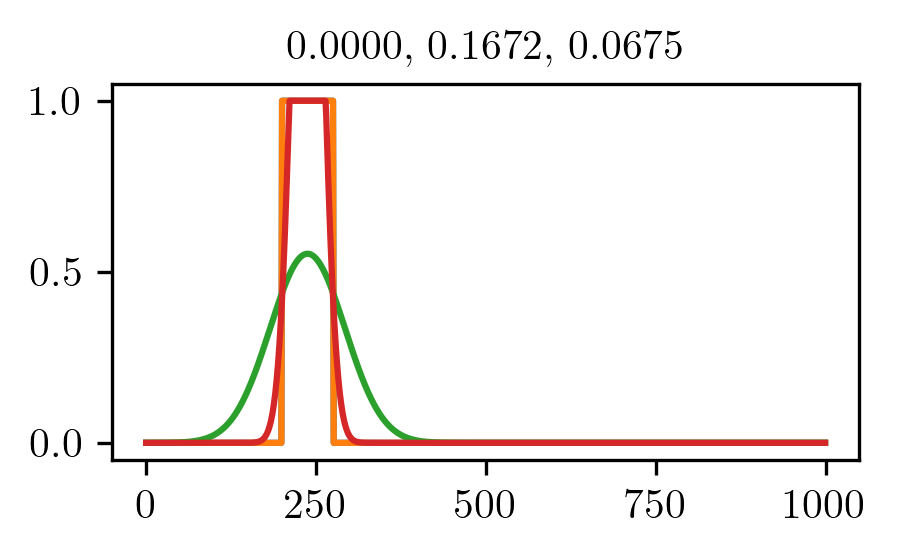

In [13]:
n = 21
rank = 21
shape = (m,)

_X_train = np.empty((m, n))
_mu_train = np.linspace(0, 1, n, endpoint=True)[:, None]
for j, mu_j in enumerate(_mu_train):
    _X_train[:, j] = pulse(x, mu_j)

improvement, X_test_ROM, X_test_sROM, X_test_sROMs = zielfunktion([0.05, 2.0], x, _mu_train, _X_train, mu_test,
                                                                  X_test, rank, shape, num_iter2)

_X_train_s = smoothen(_X_train, sigma/dx, shape)

for j, mu_j in enumerate(mu_test):
    eR = np.mean((X_test_ROM[:, j]-X_test[:, j])**2)**.5
    esR = np.mean((X_test_sROM[:, j]-X_test[:, j])**2)**.5
    esRs = np.mean((X_test_sROMs[:, j]-X_test[:, j])**2)**.5
    print(eR, esR, esRs)
    plt.plot(X_test[:, j])
    plt.plot(X_test_ROM[:, j])
    plt.plot(X_test_sROM[:, j])
    plt.plot(X_test_sROMs[:, j])
    plt.title("{:.4f}, {:.4f}, {:.4f}".format(eR, esR, esRs))
    plt.show()

In [13]:
13//2

6

In [29]:
# increase n, error? improvement?
sigma_opt, c_opt = 0.05, 4
for n in np.arange(3, 100, 1):
    rank=n
    sigma_opt = 0.9117*n**(-1.305)
    c_opt = 37.039*n**(-0.93)

    # generate training data
    X_train = np.empty((m, n))
    mu_train = np.linspace(0, 1, n, endpoint=True)[:, None]#
    for j, mu_j in enumerate(mu_train):
        X_train[:, j] = pulse(x, mu_j)
    
    # generate test data
    n1 = n//2
    n_test = 10
    mu_test = np.linspace(mu_train[n1, 0], mu_train[n1+1, 0], n_test, endpoint=False)[:, None]
    X_test = np.empty((m, n_test))
    for j, mu_j in enumerate(mu_test):
        X_test[:, j] = pulse(x, mu_j)
        
    # standard ROM
    standard_rom = train_ROM(mu_train, X_train, rank=rank)
    #X_test_ROM = standard_rom.predict(mu_test).T
    X_val_ROM = standard_rom.predict(mu_val).T
    eROM = L2_error(X_val_ROM, X_val)

    # optimize using test set
    #x0 = np.array([sigma, 2])
    x0 = np.array([sigma_opt, c_opt])
    # n2 0.032075, 6.0601, 0.05107709, -70.3 %
    # 0.029052, 5.2371, 0.10354153, -39.7 %
    zf =  lambda x0: zielfunktion(x0, x, mu_train, X_train, mu_test, X_test, rank, shape, 100)[0]
    #res = minimize(zf, x0, method='nelder-mead', bounds=[(0, 1), (-1, 10)], options={'disp': True, "fatol": 1e-2})
    #res = minimize(zf, x0, method='Powell', bounds=[(0, 1), (-1, 10)], options={'disp': True, "fatol": 1e-2})
    #res = minimize(zf, x0, method='BFGS', options={'disp': True, "eps": np.array([.001, 0.1]), "maxiter": 50})
    #res = minimize(zf, x0, method='COBYLA', bounds=[(0, 1), (-1, 10)], options={'disp': True, "rhobeg": np.array([.025, 0.5]), "maxiter": 50})
    res = minimize(zf, x0, method='SLSQP', bounds=[(0.001, 0.25), (-1, 10)], options={'disp': True, "eps": np.array([.001, 0.1]), "maxiter": 20, "ftol": 0.001})
    sigma_opt, c_opt = res["x"]
    for n_iter in [10, 20, 50, 100, 200, 500]:
        print(n, n_iter, end=", ", sep=", ")
        _i, _R, _sR, _sRs = zielfunktion(res["x"], x, mu_train, X_train, mu_test, X_test, rank, shape, n_iter)
if False:
    # regularized ROM
    X_train_s = smoothen(X_train, sigma_opt/dx, shape)
    smooth_rom = train_ROM(mu_train, X_train_s, rank=rank)
    X_test_sROM = smooth_rom.predict(mu_test).T
    X_val_sROM = smooth_rom.predict(mu_val).T
    esROM = L2_error(X_val_sROM, X_val)
    
    # double checking: run target function again with optimal values
    _i, _R, _sR, _sRs = zielfunktion(res["x"], x, mu_train, X_train, mu_test, X_test, rank, shape, num_iter2)
    # de smoothing
    X_val_sROMs = post_process(x, X_val_sROM, sigma_opt, c_opt, mu_val, mu_train,
                                num_iter1, shape=shape, clip=clip)
    esROMs = L2_error(X_val_sROMs, X_val)
    # de smoothing with a higher number of iterations
    X_val_sROMs2 = post_process(x, X_val_sROM, sigma_opt, c_opt, mu_val, mu_train,
                                num_iter2, shape=shape, clip=clip)
    esROMs2 = L2_error(X_val_sROMs2, X_val)

    print("$\|u_{rb}-u_h\|_{L_2}=$", np.mean(eROM), np.mean(eROM)/np.mean(eROM))
    print("$\|u_{rb,S}-u_h\|_{L_2}=$", np.mean(esROM), np.mean(esROM)/np.mean(eROM))
    print("$\|u_{rb, D_{10}}-u_h\|_{L_2}=$", np.mean(esROMs), np.mean(esROMs)/np.mean(eROM))
    print("$\|u_{rb, D_{100}}-u_h\|_{L_2}=$", np.mean(esROMs2), np.mean(esROMs2)/np.mean(eROM))

    # plot results
    fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
    plt.plot(mu_val, eROM, "C0o-", ms=4, markevery=(20, markevery), label="$u_{rb}$")
    plt.plot(mu_val, esROM, "C1--", ms=4, markevery=markevery, label="$u_{rb,S}$")
    plt.plot(mu_val, esROMs, "C2x-", ms=4, markevery=(20, markevery), label="$u_{rb,D_{10}}$")
    plt.plot(mu_val, esROMs2, "C3<-", ms=4, markevery=(20, markevery), label="$u_{rb,D_{100}}$")
    plt.legend()
    plt.ylabel("$\|u_{rb}-u_h\|_{L_2}$")
    plt.xlabel("$\mu$")
    plt.xlim(0, 1)
    plt.ylim(0, 0.4)
    plt.legend()
    ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
    ax.set_yticks(np.linspace(0, .4, 19, endpoint=True), minor=True)
    plt.grid(True, which='minor', linestyle='--', lw=.25)
    plt.grid(True, which='major', linestyle='-')
    plt.show()
    print(res)

0.21737456, 10.00000000, 0.27117138, 0.25970766, 0.26174336, -3.4768 %
0.21837456, 10.00000000, 0.27117138, 0.25972599, 0.26185570, -3.4354 %
0.21737456, 9.90000000, 0.27117138, 0.25970766, 0.26154935, -3.5483 %
0.00100000, 9.28457414, 0.27117138, 0.27262529, 0.27502424, 1.4208 %
0.14605148, 9.76417571, 0.27117138, 0.25875035, 0.25557396, -5.7519 %
0.14705148, 9.76417571, 0.27117138, 0.25875592, 0.25566996, -5.7165 %
0.14605148, 9.86417571, 0.27117138, 0.25875035, 0.25569350, -5.7078 %
0.00100000, 9.78266983, 0.27117138, 0.27262529, 0.27526364, 1.5091 %
0.11603632, 9.76800266, 0.27117138, 0.25878527, 0.26001704, -4.1134 %
0.14015340, 9.76492772, 0.27117138, 0.25872486, 0.25463765, -6.0972 %
0.14115340, 9.76492772, 0.27117138, 0.25872826, 0.25479612, -6.0387 %
0.14015340, 9.86492772, 0.27117138, 0.25872486, 0.25482780, -6.0270 %
0.00100000, 9.00483483, 0.27117138, 0.27262529, 0.27495213, 1.3942 %
0.10283863, 9.56110454, 0.27117138, 0.25897313, 0.26179411, -3.4581 %
0.13141799, 9.7172126

0.04081496, 8.63396121, 0.25593337, 0.22675729, 0.09263205, -63.8062 %
0.06217492, 6.18589528, 0.25593337, 0.22564448, 0.07906319, -69.1079 %
0.06317492, 6.18589528, 0.25593337, 0.22575204, 0.07935587, -68.9935 %
0.06217492, 6.28589528, 0.25593337, 0.22564448, 0.07921058, -69.0503 %
0.06295721, 5.09716395, 0.25593337, 0.22572782, 0.08017049, -68.6753 %
0.06239164, 5.88428762, 0.25593337, 0.22566698, 0.07893450, -69.1582 %
0.06339164, 5.88428762, 0.25593337, 0.22577658, 0.07902947, -69.1211 %
0.06239164, 5.98428762, 0.25593337, 0.22566698, 0.07894634, -69.1536 %
0.05255077, 7.30854592, 0.25593337, 0.22519694, 0.08093544, -68.3764 %
0.06102962, 6.08141046, 0.25593337, 0.22553329, 0.07890851, -69.1683 %
0.06202962, 6.08141046, 0.25593337, 0.22562965, 0.07895139, -69.1516 %
0.06102962, 6.18141046, 0.25593337, 0.22553329, 0.07891163, -69.1671 %
0.05968174, 6.28719537, 0.25593337, 0.22541996, 0.07895347, -69.1508 %
0.06067019, 6.13628556, 0.25593337, 0.22550116, 0.07891326, -69.1665 %
0.0608

0.00842225, 10.00000000, 0.21249430, 0.20510764, 0.24896125, 17.1614 %
0.04291300, 5.26314878, 0.21249430, 0.19613632, 0.05555038, -73.8579 %
0.04391300, 5.26314878, 0.21249430, 0.19659195, 0.05564210, -73.8148 %
0.04291300, 5.36314878, 0.21249430, 0.19613632, 0.05549819, -73.8825 %
0.02778938, 9.43702672, 0.21249430, 0.19280638, 0.05909552, -72.1896 %
0.03912125, 6.30961069, 0.21249430, 0.19459344, 0.05503764, -74.0992 %
0.04012125, 6.30961069, 0.21249430, 0.19496832, 0.05510308, -74.0684 %
0.03912125, 6.40961069, 0.21249430, 0.19459344, 0.05500851, -74.1130 %
0.03273639, 7.98045427, 0.21249430, 0.19292937, 0.05586263, -73.7110 %
0.03745154, 6.74655464, 0.21249430, 0.19402775, 0.05500548, -74.1144 %
0.03845154, 6.74655464, 0.21249430, 0.19435706, 0.05498480, -74.1241 %
0.03745154, 6.84655464, 0.21249430, 0.19402775, 0.05495749, -74.1370 %
0.02855871, 10.00000000, 0.21249430, 0.19274412, 0.05700417, -73.1738 %
0.03563751, 7.41021974, 0.21249430, 0.19351005, 0.05502243, -74.1064 %
0.036

12, 100, 0.03543322, 4.63779553, 0.17420025, 0.17303392, 0.05120623, -70.6050 %
12, 200, 0.03543322, 4.63779553, 0.17420025, 0.17303392, 0.04524656, -74.0261 %
12, 500, 0.03543322, 4.63779553, 0.17420025, 0.17303392, 0.04377274, -74.8722 %
0.03207420, 3.40950974, 0.16262009, 0.16483348, 0.05168460, -68.2176 %
0.03307420, 3.40950974, 0.16262009, 0.16588029, 0.05116736, -68.5356 %
0.03207420, 3.50950974, 0.16262009, 0.16483348, 0.05142237, -68.3788 %
0.25000000, 5.02206696, 0.16262009, 0.25321563, 0.24046995, 47.8722 %
0.07375462, 3.71792693, 0.16262009, 0.20583905, 0.06561871, -59.6491 %
0.04491510, 3.50452687, 0.16262009, 0.17899343, 0.05122393, -68.5009 %
0.03895461, 3.46042181, 0.16262009, 0.17233186, 0.05012183, -69.1786 %
0.03995461, 3.46042181, 0.16262009, 0.17345334, 0.05021997, -69.1182 %
0.03895461, 3.56042181, 0.16262009, 0.17233186, 0.05010202, -69.1908 %
0.01207982, 10.00000000, 0.16262009, 0.15373825, 0.07582405, -53.3735 %
0.03626713, 4.11437963, 0.16262009, 0.16933907, 0.

0.02546107, 2.81078527, 0.13818746, 0.14363115, 0.05386970, -61.0169 %
0.02446107, 2.91078527, 0.13818746, 0.14228472, 0.05485856, -60.3013 %
0.24999999, 7.42833572, 0.13818746, 0.25299277, 0.25744557, 86.3017 %
0.09917002, 4.34033216, 0.13818746, 0.21992684, 0.08634228, -37.5180 %
0.05470979, 3.43007977, 0.13818746, 0.18460590, 0.05382588, -61.0486 %
0.04007615, 3.13047926, 0.13818746, 0.16517051, 0.04987493, -63.9078 %
0.04107615, 3.13047926, 0.13818746, 0.16662513, 0.04993840, -63.8618 %
0.04007615, 3.23047926, 0.13818746, 0.16517051, 0.04991198, -63.8810 %
0.05593570, -1.00000000, 0.13818746, 0.18603293, 0.15075307, 9.0932 %
0.04166210, 2.71743133, 0.13818746, 0.16747057, 0.04988170, -63.9029 %
0.04077839, 2.94758571, 0.13818746, 0.16619352, 0.04985801, -63.9200 %
0.04177839, 2.94758571, 0.13818746, 0.16763772, 0.04993885, -63.8615 %
0.04077839, 3.04758571, 0.13818746, 0.16619352, 0.04988857, -63.8979 %
0.04011559, 2.78350763, 0.13818746, 0.16522815, 0.04978141, -63.9755 %
0.041115

...

0.00400509, 1.49989231, 0.05494990, 0.05365176, 0.03072935, -44.0775 %
0.00409129, 1.44599459, 0.05494990, 0.05387114, 0.03072344, -44.0883 %
0.00509129, 1.44599459, 0.05494990, 0.05663911, 0.02883361, -47.5274 %
0.00409129, 1.54599459, 0.05494990, 0.05387114, 0.02965936, -46.0247 %
0.00207169, 2.91200268, 0.05494990, 0.05052499, 0.05168867, -5.9349 %
0.00372796, 1.70973086, 0.05494990, 0.05297573, 0.03075032, -44.0394 %
0.00391190, 1.57621163, 0.05494990, 0.05341924, 0.03059527, -44.3215 %
0.00491190, 1.57621163, 0.05494990, 0.05611904, 0.02888690, -47.4305 %
0.00391190, 1.67621163, 0.05494990, 0.05341924, 0.02963414, -46.0706 %
0.00224988, 2.78712510, 0.05494990, 0.05059765, 0.04712496, -14.2401 %
0.00362321, 1.78654385, 0.05494990, 0.05273326, 0.03097262, -43.6348 %
0.00379614, 1.66055410, 0.05494990, 0.05313759, 0.03065192, -44.2184 %
0.00385892, 1.61481477, 0.05494990, 0.05328930, 0.03060557, -44.3028 %
0.00388635, 1.59482972, 0.05494990, 0.05335636, 0.03059704, -44.3183 %
0.00389

0.02665730, 0.14733485, 0.05676937, 0.11517510, 0.04815438, -15.1754 %
0.02654335, 0.27010381, 0.05676937, 0.11488347, 0.04704838, -17.1236 %
0.02754335, 0.27010381, 0.05676937, 0.11744407, 0.04740490, -16.4956 %
0.02654335, 0.37010381, 0.05676937, 0.11488347, 0.04787617, -15.6655 %
0.00100000, -0.19407840, 0.05676937, 0.05364589, 0.05564906, -1.9734 %
0.01886893, 0.13064172, 0.05676937, 0.09549977, 0.04447183, -21.6623 %
0.01986893, 0.13064172, 0.05676937, 0.09800611, 0.04506889, -20.6105 %
0.01886893, 0.23064172, 0.05676937, 0.09549977, 0.04287986, -24.4666 %
0.00100000, -0.03124872, 0.05676937, 0.05364589, 0.05615915, -1.0749 %
0.01521381, 0.09752675, 0.05676937, 0.08616990, 0.04354397, -23.2967 %
0.01621381, 0.09752675, 0.05676937, 0.08876582, 0.04403396, -22.4336 %
0.01521381, 0.19752675, 0.05676937, 0.08616990, 0.04057022, -28.5350 %
0.00310381, 0.13301757, 0.05676937, 0.05277273, 0.05562034, -2.0240 %
0.01299412, 0.10403201, 0.05676937, 0.08022183, 0.04259962, -24.9602 %
0.01399

0.00549555, 1.11247103, 0.05612199, 0.05761168, 0.02792907, -50.2351 %
0.00443487, 1.46483900, 0.05612199, 0.05463259, 0.02892528, -48.4600 %
0.00498782, 1.22901299, 0.05612199, 0.05613949, 0.02846372, -49.2824 %
0.00598782, 1.22901299, 0.05612199, 0.05908967, 0.02766688, -50.7023 %
0.00498782, 1.32901299, 0.05612199, 0.05613949, 0.02783158, -50.4088 %
0.00363028, 1.80459950, 0.05612199, 0.05273998, 0.03229932, -42.4480 %
0.00471633, 1.34412179, 0.05612199, 0.05538418, 0.02857882, -49.0773 %
0.00487701, 1.27599196, 0.05612199, 0.05582805, 0.02848618, -49.2424 %
0.00493780, 1.25022001, 0.05612199, 0.05599840, 0.02847034, -49.2706 %
0.00496445, 1.23892026, 0.05612199, 0.05607348, 0.02846619, -49.2780 %
0.00497675, 1.23370312, 0.05612199, 0.05610822, 0.02846473, -49.2806 %
0.00498254, 1.23124942, 0.05612199, 0.05612458, 0.02846416, -49.2816 %
0.00498529, 1.23008340, 0.05612199, 0.05613235, 0.02846392, -49.2821 %
0.00498660, 1.22952635, 0.05612199, 0.05613607, 0.02846381, -49.2822 %
0.0049

0.00670049, 0.80687638, 0.05612199, 0.06127808, 0.02839264, -49.4091 %
0.00670207, 0.80671269, 0.05612199, 0.06128297, 0.02839243, -49.4094 %
0.00670274, 0.80664243, 0.05612199, 0.06128507, 0.02839235, -49.4096 %
0.00670304, 0.80661222, 0.05612199, 0.06128597, 0.02839231, -49.4097 %
0.00670316, 0.80659922, 0.05612199, 0.06128636, 0.02839230, -49.4097 %
Optimization terminated successfully    (Exit mode 0)
            Current function value: -49.40968072231101
            Iterations: 10
            Function evaluations: 49
            Gradient evaluations: 10
97, 10, 0.00670316, 0.80659922, 0.05612199, 0.06128636, 0.04245291, -24.3560 %
97, 20, 0.00670316, 0.80659922, 0.05612199, 0.06128636, 0.03752965, -33.1285 %
97, 50, 0.00670316, 0.80659922, 0.05612199, 0.06128636, 0.03187196, -43.2095 %
97, 100, 0.00670316, 0.80659922, 0.05612199, 0.06128636, 0.02839230, -49.4097 %
97, 200, 0.00670316, 0.80659922, 0.05612199, 0.06128636, 0.02591814, -53.8182 %
97, 500, 0.00670316, 0.80659922, 0.056

0.00100000, -0.05490103, 0.05612199, 0.05293221, 0.05560157, -0.9273 %
0.01899109, 0.19180501, 0.05612199, 0.09565950, 0.04147415, -26.1000 %
0.01999109, 0.19180501, 0.05612199, 0.09816501, 0.04213052, -24.9305 %
0.01899109, 0.29180501, 0.05612199, 0.09565950, 0.04080941, -27.2845 %
0.00100000, -0.02038946, 0.05612199, 0.05293221, 0.05572419, -0.7088 %
0.01519617, 0.14704610, 0.05612199, 0.08594970, 0.04008118, -28.5820 %
0.01619617, 0.14704610, 0.05612199, 0.08855820, 0.04067772, -27.5191 %
0.01519617, 0.24704610, 0.05612199, 0.08594970, 0.03776329, -32.7121 %
0.00201853, 0.12055852, 0.05612199, 0.05118366, 0.05504288, -1.9228 %
0.01304615, 0.14272447, 0.05612199, 0.08015270, 0.03934518, -29.8935 %
0.01404615, 0.14272447, 0.05612199, 0.08288450, 0.03966092, -29.3309 %
0.01304615, 0.24272447, 0.05612199, 0.08015270, 0.03630623, -35.3084 %
0.00956927, 0.20219155, 0.05612199, 0.07010605, 0.03793556, -32.4052 %
0.01056927, 0.20219155, 0.05612199, 0.07308456, 0.03730146, -33.5350 %
0.00956

In [ ]:
_i, _R, _sR, _sRs = zielfunktion(res["x"], x, mu_train, X_train, mu_test, X_test, rank, shape, num_iter1)
print(L2_error(_sR, X_test))
print(L2_error(_sRs, X_test))

_sRs2 = post_process(x, X_test_sROM, sigma_opt, c_opt, mu_test, mu_train,
                            num_iter1, shape=shape, clip=clip)
for j in range(len(mu_test)):
    plt.plot(x, X_test[:, j])
    plt.plot(x, _sR[:, j])
    plt.plot(x, _sRs[:, j])
    plt.plot(x, _sRs2[:, j], "k--", lw=1)
    plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
plt.plot(mu_val, eROM, "C0o-", ms=4, markevery=(20, markevery), label="$u_{rb}$")
plt.plot(mu_val, esROM, "C1--", ms=4, markevery=markevery, label="$u_{rb,S}$")
plt.plot(mu_val, esROMs, "C2x-", ms=4, markevery=(20, markevery), label="$u_{rb,D_{10}}$")
plt.plot(mu_val, esROMs2, "C3<-", ms=4, markevery=(20, markevery), label="$u_{rb,D_{100}}$")
plt.legend()
plt.ylabel("$\|u_{rb}-u_h\|_{L_2}$")
plt.xlabel("$\mu$")
ax.set_xticks(np.linspace(0, 1, 11, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, .4, 19, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
plt.xlim(0.2, .25)
plt.ylim(0, 0.2)
plt.show()